# **EXOPLANET HABITABILITY CLASSIFICATION PROJECT**

### RIDIMA

This notebook is a ML project, classifying exoplanets on their habitability from various mission data. 

In [1]:
#Import all the essentials libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel

#Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn import tree
from sklearn.naive_bayes import GaussianNB

In [2]:
#Open the data
df = pd.read_csv("phl_exoplanet_catalog_2019.csv")
df.head()

,P_NAME,P_STATUS,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,...,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST
0,11 Com b,3.0,6165.86330,-476.74200,476.74200,NaN,NaN,NaN,2007,2014-05-14,...,0,Hot,0,0.083813,Coma Berenices,Com,Berenice's Hair,12.082709,6165.86330,1.29
1,11 UMi b,3.0,4684.78480,-794.57001,794.57001,NaN,NaN,NaN,2009,2018-09-06,...,0,Hot,0,0.082414,Ursa Minor,UMi,Little Bear,12.229641,4684.78480,1.53
2,14 And b,3.0,1525.57440,NaN,NaN,NaN,NaN,NaN,2008,2014-05-14,...,0,Hot,0,0.081917,Andromeda,And,Andromeda,12.848516,1525.57440,0.83
3,14 Her b,3.0,1481.07850,-47.67420,47.67420,NaN,NaN,NaN,2002,2018-09-06,...,0,Cold,0,0.145241,Hercules,Her,Hercules,12.865261,1481.07850,2.93
4,16 Cyg B b,3.0,565.73385,-25.42624,25.42624,NaN,NaN,NaN,1996,2018-09-06,...,1,Warm,0,0.368627,Cygnus,Cyg,Swan,13.421749,565.73385,1.66


In [3]:
df.columns

Index(['P_NAME', 'P_STATUS', 'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX',
       'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_YEAR',
       'P_UPDATED',
       ...
       'P_HABZONE_CON', 'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI',
       'S_CONSTELLATION', 'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG',
       'P_RADIUS_EST', 'P_MASS_EST', 'P_SEMI_MAJOR_AXIS_EST'],
      dtype='object', length=112)

In [4]:
shape = df.shape
print(f'Rows: {shape[0]}')
print(f'Columns: {shape[1]}')

Rows: 4048
Columns: 112


In [5]:
null_vales = df.isnull().sum().sort_values(ascending = False)
null_vales.head(40)

P_ATMOSPHERE                    4048
P_ALT_NAMES                     4048
P_DETECTION_RADIUS              4048
P_GEO_ALBEDO                    4048
P_DETECTION_MASS                4048
S_MAGNETIC_FIELD                4048
S_DISC                          4048
P_TEMP_MEASURED                 4043
P_GEO_ALBEDO_ERROR_MIN          4043
P_GEO_ALBEDO_ERROR_MAX          4043
P_TPERI_ERROR_MAX               3576
P_TPERI_ERROR_MIN               3576
P_TPERI                         3567
P_OMEGA_ERROR_MIN               3355
P_OMEGA_ERROR_MAX               3355
P_ESCAPE                        3342
P_POTENTIAL                     3342
P_DENSITY                       3342
P_GRAVITY                       3342
P_OMEGA                         3302
P_INCLINATION_ERROR_MAX         3238
P_INCLINATION_ERROR_MIN         3236
P_INCLINATION                   3204
P_ECCENTRICITY_ERROR_MIN        3077
P_ECCENTRICITY_ERROR_MAX        3077
S_TYPE                          2678
P_ECCENTRICITY                  2668
P

### **PREPRCESSING**

<Axes: >

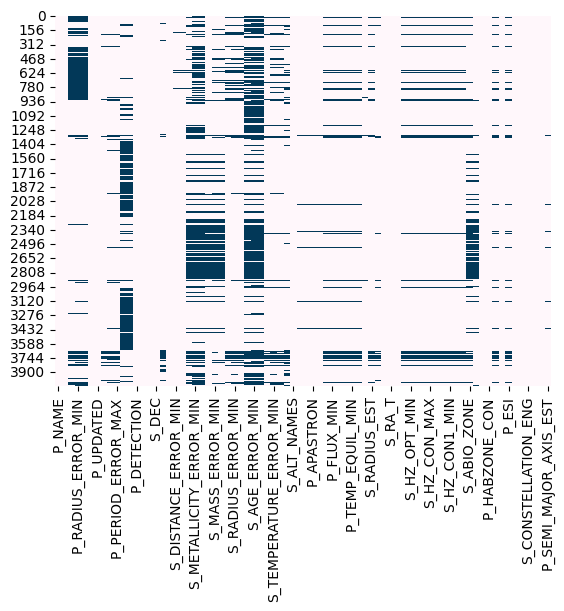

In [ ]:
#Plots a heatmap of the missing values in the dataset
sns.heatmap(df.isnull(), cbar=False, cmap='PuBu') 

In [10]:
df.isnull().sum().sort_values(ascending=False)

S_AGE_ERROR_MAX        2161
S_AGE_ERROR_MIN        2161
S_AGE                  2017
P_ANGULAR_DISTANCE     1687
P_SEMI_MAJOR_AXIS      1681
                       ... 
P_HABITABLE               0
S_CONSTELLATION_ABR       0
S_CONSTELLATION_ENG       0
P_RADIUS_EST              0
P_MASS_EST                0
Length: 76, dtype: int64

In [ ]:
#Dropping all the columns with null  values
df = df.drop(["P_DETECTION_MASS", "P_GEO_ALBEDO", "S_MAGNETIC_FIELD", "S_DISC", "P_ATMOSPHERE", "P_ALT_NAMES", "P_DETECTION_RADIUS", "P_GEO_ALBEDO_ERROR_MIN", "P_TEMP_MEASURED", "P_GEO_ALBEDO_ERROR_MAX","P_TPERI_ERROR_MAX", "P_TPERI_ERROR_MIN", "P_TPERI", "P_OMEGA_ERROR_MIN", "P_OMEGA_ERROR_MAX", "P_DENSITY", "P_ESCAPE", "P_POTENTIAL", "P_GRAVITY", "P_OMEGA",   "P_INCLINATION_ERROR_MAX", "P_INCLINATION_ERROR_MIN", "P_INCLINATION", "P_ECCENTRICITY_ERROR_MAX", "P_ECCENTRICITY_ERROR_MIN", "S_TYPE", "P_ECCENTRICITY","P_IMPACT_PARAMETER_ERROR_MIN", "P_IMPACT_PARAMETER_ERROR_MAX", "P_IMPACT_PARAMETER", "P_MASS_ERROR_MAX", "P_MASS_ERROR_MIN", "P_HILL_SPHERE", "P_SEMI_MAJOR_AXIS_ERROR_MIN", "P_SEMI_MAJOR_AXIS_ERROR_MAX", "P_MASS"], axis=1)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4048 entries, 0 to 4047
Data columns (total 76 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   P_NAME                   4048 non-null   object 
 1   P_STATUS                 4048 non-null   float64
 2   P_RADIUS                 3139 non-null   float64
 3   P_RADIUS_ERROR_MIN       3105 non-null   float64
 4   P_RADIUS_ERROR_MAX       3105 non-null   float64
 5   P_YEAR                   4048 non-null   int64  
 6   P_UPDATED                4048 non-null   object 
 7   P_PERIOD                 3938 non-null   float64
 8   P_PERIOD_ERROR_MIN       3807 non-null   float64
 9   P_PERIOD_ERROR_MAX       3807 non-null   float64
 10  P_SEMI_MAJOR_AXIS        2367 non-null   float64
 11  P_ANGULAR_DISTANCE       2361 non-null   float64
 12  P_DETECTION              4048 non-null   object 
 13  S_NAME                   4048 non-null   object 
 14  S_RA                    

Our data is divided into categorical and numeric datatypes

In [13]:
#Null values in the categorical data columns
df.select_dtypes(include=['object']).isnull().sum().sort_values(ascending=False)

P_TYPE_TEMP            327
S_TYPE_TEMP            136
P_TYPE                  17
P_UPDATED                0
P_NAME                   0
S_ALT_NAMES              0
S_NAME                   0
P_DETECTION              0
S_RA_T                   0
S_DEC_T                  0
S_CONSTELLATION          0
S_CONSTELLATION_ABR      0
S_CONSTELLATION_ENG      0
dtype: int64

In [14]:
print(df['P_TYPE'])
df['P_TYPE'].isnull().sum()

0            Jovian
1            Jovian
2            Jovian
3            Jovian
4            Jovian
           ...     
4043    Superterran
4044      Neptunian
4045         Terran
4046         Terran
4047         Terran
Name: P_TYPE, Length: 4048, dtype: object


np.int64(17)

The “P_TYPE” column in our data describes the exoplanet category and consists of six possible values: Jovian, Superterran, Neptunian, Terran, Subterran, and Miniterran. This feature had 17 missing values.

TO handle the missing values, we can impute them using mode

In [15]:
df['P_TYPE'] = df['P_TYPE'].fillna(df['P_TYPE'].mode()[0]) #set the first most common value
df['P_TYPE_TEMP'] = df['P_TYPE_TEMP'].fillna(df['P_TYPE_TEMP'].mode()[0])
df['S_TYPE_TEMP'] = df['S_TYPE_TEMP'].fillna(df['S_TYPE_TEMP'].mode()[0]) 

In [16]:
#Converting sll the categorical data into integer data
lencoders = {}
for col in df.select_dtypes(include=['object']).columns:
    lencoders[col] = LabelEncoder()
    df[col] = lencoders[col].fit_transform(df[col])

nOw WE HANDLED MISSING VALUES IN CATEGORICAL DATA and encoded them, NO WE WILL WORK UPON NUMERICAL DATA 

We are going to use Scikit-learn's imputer because it provides a systematic way to replace missing numerical data, and IterativeImputer is particularly useful when we want to use relationships between multiple features to make those replacements.


In [17]:
imp = IterativeImputer(max_iter=10, verbose=0) #Creates an iterative imputer object
imp.fit(df) #Fits the imputer to the dataframe
imputed_df = imp.transform(df) #Transforms the data
df = pd.DataFrame(imputed_df, columns=df.columns) #Creates a dataframe from the imputed data. 

In [20]:
# Checking for missing values
df.isnull().sum().sort_values(ascending=False)

P_NAME                   0
P_STATUS                 0
P_RADIUS                 0
P_RADIUS_ERROR_MIN       0
P_RADIUS_ERROR_MAX       0
                        ..
S_CONSTELLATION_ENG      0
P_RADIUS_EST             0
P_MASS_EST               0
P_SEMI_MAJOR_AXIS_EST    0
P_HABITABLE              0
Length: 76, dtype: int64

we have corrected all of our missing values! But, we still have a major class imbalance to work with. Since we don’t know of many potentially habitable planets, the number of inhabitable exoplanets greatly outnumbers the habitable ones. This will likely cause our model to guess an exoplanet is inhabitable, even if it’s not the case, because it will still have an average of like 99% accuracy. Thus, we need to find a way to balance the scales.

We will use upsampling method, using algorithm SMOTE.

In [18]:
X= df.iloc[:, df.columns != 'P_HABITABLE']
y = df['P_HABITABLE']
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_res, y_res = smote.fit_resample(X,y)

df = pd.concat([pd.DataFrame(X_res), pd.DataFrame(y_res)], axis = 1 )
df.head()

,P_NAME,P_STATUS,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_YEAR,P_UPDATED,P_PERIOD,P_PERIOD_ERROR_MIN,P_PERIOD_ERROR_MAX,...,P_HABZONE_CON,P_TYPE_TEMP,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG,P_RADIUS_EST,P_MASS_EST,P_SEMI_MAJOR_AXIS_EST,P_HABITABLE
0,0.0,3.0,4.798394,8.410642,-2.004052,2007.0,0.0,326.03000,-0.32,0.32,...,0.0,1.0,0.083813,24.0,24.0,5.0,12.082709,6165.86330,1.29,0.0
1,1.0,3.0,4.798394,8.410642,-2.004052,2009.0,146.0,516.21997,-3.20,3.20,...,0.0,1.0,0.082414,83.0,83.0,42.0,12.229641,4684.78480,1.53,0.0
2,2.0,3.0,4.798394,8.410642,-2.004052,2008.0,0.0,185.84000,-0.23,0.23,...,0.0,1.0,0.081917,0.0,0.0,2.0,12.848516,1525.57440,0.83,0.0
3,3.0,3.0,4.798394,8.410642,-2.004052,2002.0,146.0,1773.40000,-2.50,2.50,...,0.0,0.0,0.145241,39.0,39.0,34.0,12.865261,1481.07850,2.93,0.0
4,4.0,3.0,4.798394,8.410642,-2.004052,1996.0,146.0,798.50000,-1.00,1.00,...,1.0,2.0,0.368627,30.0,30.0,75.0,13.421749,565.73385,1.66,0.0


In [23]:
# Checking if imbalance is fixed
df['P_HABITABLE'].value_counts()

P_HABITABLE
0.0    3993
2.0    3993
1.0    3993
Name: count, dtype: int64

In [21]:
df.shape

(11979, 76)

After balancing the data, we can now move to visualize the data

First we will visualise it using a correlation heatmap as the model might learn correlations that aren’t really related to the actual habitability of the planet.

<Axes: >

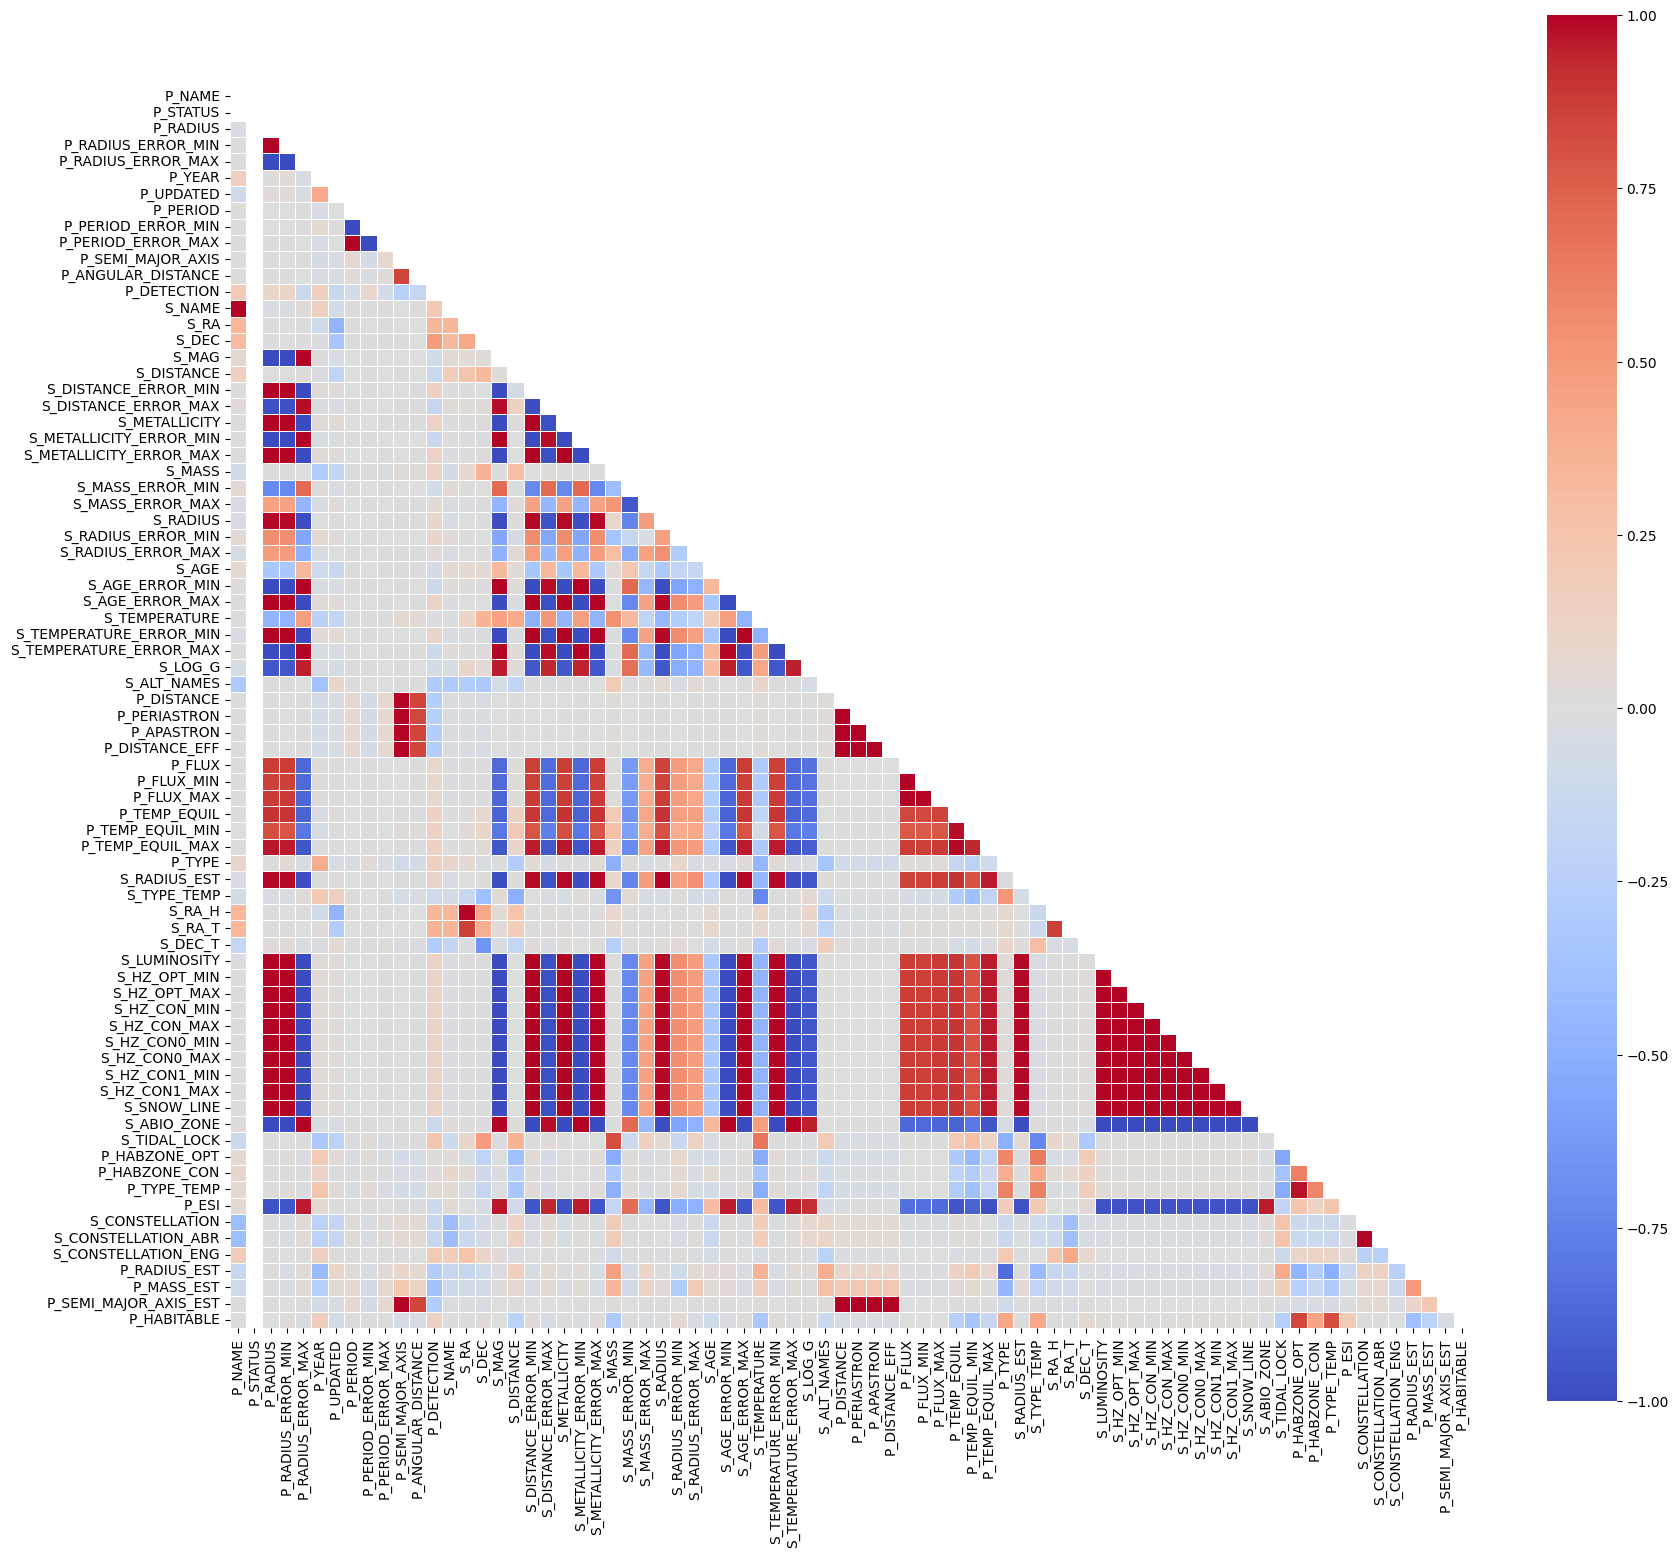

In [24]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

The dark red squares indicate that the two corresponding variables are highly related to one another and might cause unwanted connections in our machine learning model.

In [25]:
#Dropping one of each which are highly corelated to each other
working_data = df.drop([ 'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_DISTANCE', 'P_PERIASTRON', 'P_APASTRON', 'P_DISTANCE_EFF', 'P_FLUX_MIN', 'P_FLUX_MAX', 'P_TEMP_EQUIL', 'P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'S_RADIUS_EST', 'S_RA_H', 'S_RA_T', 'S_LUMINOSITY', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_SNOW_LINE', 'P_PERIOD_ERROR_MIN',  'P_PERIOD_ERROR_MAX', 'S_MAG', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_METALLICITY', 'S_METALLICITY_ERROR_MIN', 'S_METALLICITY_ERROR_MAX', 'S_AGE', 'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_ABIO_ZONE', 'P_ESI', 'S_CONSTELLATION_ABR', 'P_SEMI_MAJOR_AXIS_EST'], axis=1)

<Axes: >

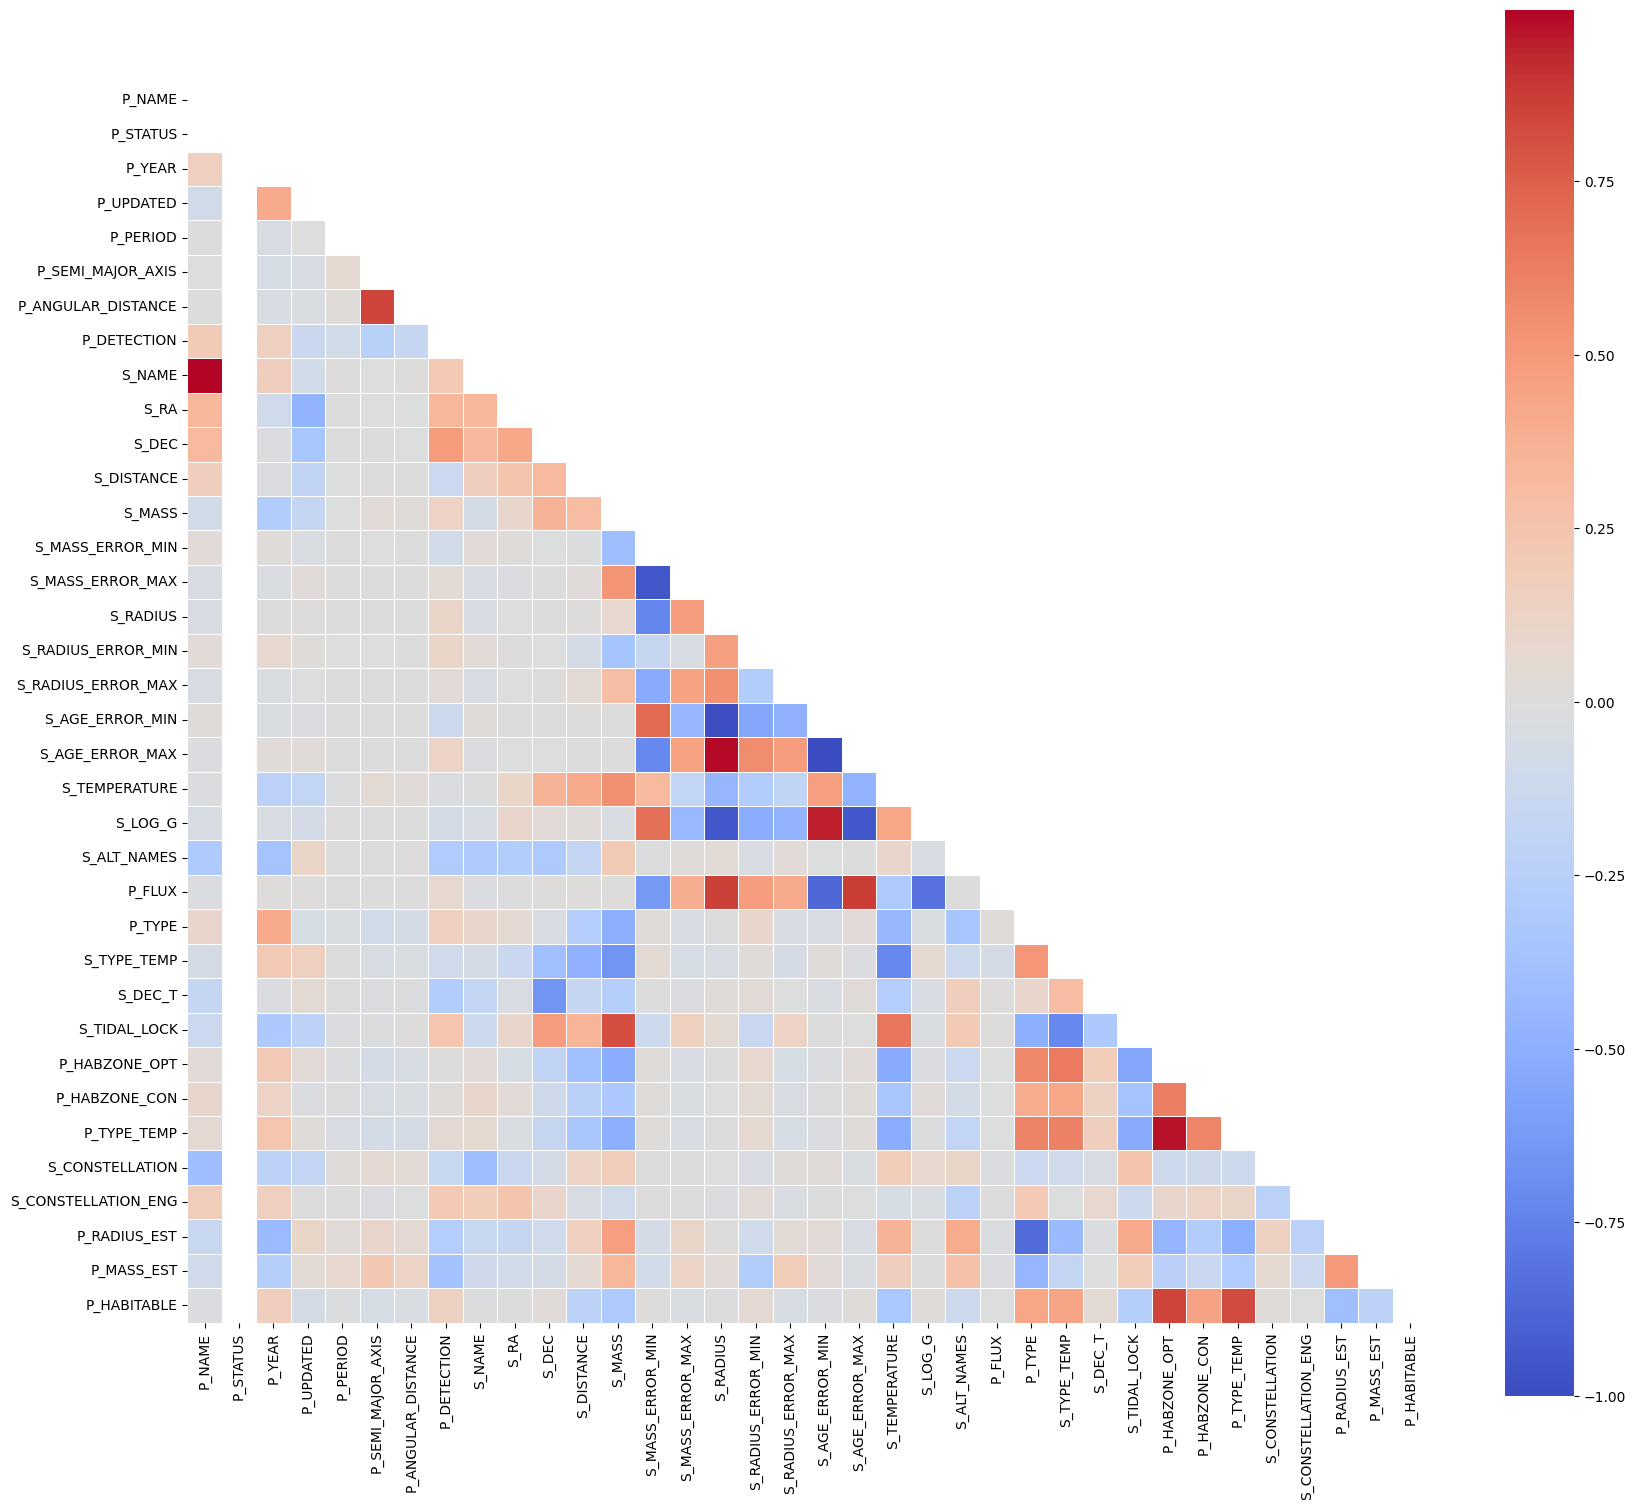

In [27]:
corr = working_data.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

In [28]:
working_data["P_STATUS"].value_counts()

P_STATUS
3.0    11979
Name: count, dtype: int64

In [30]:
#Since ther's only one value we can drop it 
working_data = working_data.drop('P_STATUS', axis = 1)

## **Splitting into Train/Test**

In [33]:
X = working_data.loc[:, working_data.columns != "P_HABITABLE"]
y = working_data["P_HABITABLE"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
print("Training/testing: ", len(X_train), '/', len(X_test))


Training/testing:  8984 / 2995


In [35]:
y_train.value_counts("P_HABITABLE")

P_HABITABLE
2.0    0.334150
1.0    0.333148
0.0    0.332703
Name: proportion, dtype: float64

## **FEATURE SELECTION**

In [40]:
feat_labels = df.columns[1:]

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

importance = forest.feature_importances_

index = np.argsort(importance)[::-1]

for i in range(X_train.shape[1]):
    print(feat_labels[index[i]], "               " ,importance[index[i]])


S_RADIUS_ERROR_MAX                 0.14184134130222908
S_MASS_ERROR_MIN                 0.13220226231659485
S_MASS                 0.12637330228951543
S_AGE_ERROR_MIN                 0.09711385535355456
S_TEMPERATURE_ERROR_MIN                 0.09320290267747783
S_TEMPERATURE_ERROR_MAX                 0.08556565291021113
S_RADIUS_ERROR_MIN                 0.0368092515428428
P_DETECTION                 0.03519599141204444
S_METALLICITY                 0.03433116050394193
P_RADIUS_ERROR_MAX                 0.03294075583647995
S_AGE                 0.02939085913282923
S_MASS_ERROR_MAX                 0.0229356522232946
S_RA                 0.017210703991034294
P_YEAR                 0.013850460718141493
S_DEC                 0.013788425836204899
P_ANGULAR_DISTANCE                 0.01363559963814862
S_METALLICITY_ERROR_MIN                 0.011037352593167571
S_NAME                 0.009065246318950958
S_AGE_ERROR_MAX                 0.007904403855090501
P_PERIOD                 0.0067238

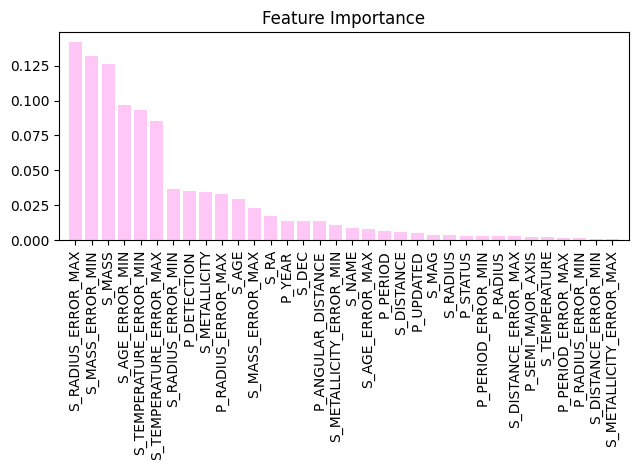

In [41]:
plt.title("Feature Importance")
plt.bar(range(X_train.shape[1]),
        importance[index],
        align = 'center', 
        color= "#ffc7f5")


plt.xticks(range(X_train.shape[1]),
        feat_labels[index], rotation=90)

plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()


In [ ]:
#We removed all those features which have importance less then 1%
sfm = SelectFromModel(forest,threshold=0.01, prefit=True)
#Created a new data frame for training and testing after removing those features which had importance < 1%
X_selected_train = pd.DataFrame(sfm.transform(X_train))
X_selected_test = pd.DataFrame(sfm.transform(X_test))

A = pd.DataFrame(X_selected_train)
B= pd.DataFrame(X_selected_test)

features = X_train.loc[:, sfm.get_support()].columns
A.columns = features
B.columns = A.columns

print('Number of training features that meet this threshold criterion:',  X_selected_train.shape[1])
print('Number of test features that meet the threshold criteria: ', X_selected_test.shape[1])

Number of training features that meet this threshold criterion: 17
Number of test features that meet the threshold criteria:  17


c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\MSII\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In A we got all the features whose feature importance was > 1% for training purpose. 

In B we got all the features whose feature importance was > 1% for testnig purpose. 

In [43]:
A.head()

,P_PERIOD,P_SEMI_MAJOR_AXIS,S_DISTANCE,S_MASS,S_MASS_ERROR_MAX,S_RADIUS,S_TEMPERATURE,S_LOG_G,P_FLUX,P_TYPE,S_TYPE_TEMP,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_RADIUS_EST,P_MASS_EST
0,239.005812,6.627737,819.672784,0.933130,0.050000,0.906426,5579.614198,4.496815,1.324365,4.0,3.000000,0.446820,1.0,0.000000,2.0,1.999821,4.679221
1,150.473969,2.674323,609.687122,0.752212,0.032842,0.707896,4835.275166,4.616421,0.982801,4.0,4.000000,0.426818,1.0,1.000000,2.0,2.034313,4.818633
2,83.889556,3.773043,175.313392,0.558924,0.025584,0.526590,4010.464426,4.775744,0.702329,4.0,4.441648,0.319794,1.0,1.000000,2.0,2.231175,5.664351
3,100.638879,4.643225,215.500622,0.540000,0.026797,0.513203,3774.711219,4.746797,0.415429,5.0,5.000000,0.364029,1.0,1.000000,2.0,1.325848,2.269959
4,32.714900,0.132385,6.193032,0.289015,0.018048,1.389004,3272.518893,4.616618,0.952228,5.0,5.000000,0.270956,1.0,0.804833,2.0,1.356890,2.387930


In [44]:
B.head()

,P_PERIOD,P_SEMI_MAJOR_AXIS,S_DISTANCE,S_MASS,S_MASS_ERROR_MAX,S_RADIUS,S_TEMPERATURE,S_LOG_G,P_FLUX,P_TYPE,S_TYPE_TEMP,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_RADIUS_EST,P_MASS_EST
0,36.069001,0.147579,6.800000,0.330000,0.020000,1.687998,3350.000000,4.690000,0.984301,5.0,5.000000,0.277482,1.0,0.728367,2.0,1.502784,2.887955
1,70.868459,4.528362,254.287601,0.543150,0.026575,0.526438,3857.449173,4.736850,1.047959,4.0,4.671240,0.345570,1.0,0.671240,2.0,2.041143,4.827754
2,162.094506,2.864301,803.596052,0.789978,0.040000,0.756091,5046.092574,4.585011,1.174970,4.0,3.611232,0.446424,1.0,0.611232,2.0,2.135517,5.207778
3,2309.336719,1.800000,6000.000000,0.370000,0.360000,0.991178,5490.154056,4.449290,158.886886,0.0,3.000000,0.331196,0.0,0.000000,1.0,13.353106,635.656010
4,19.488876,0.076014,4.406596,0.168387,0.012304,0.508998,3044.475415,4.400638,1.147263,5.0,5.000000,0.251749,1.0,0.230417,2.0,1.229452,1.932634
